# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [2]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
)

nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /Users/myko/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/myko/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
raw_df = pd.read_csv(
    "~/ML/ml_course/module_4_nlp_and_deep_learning/dataframes/tweet_sentiment_train.csv.zip"
)
raw_df.shape

(27481, 4)

In [4]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   textID         27481 non-null  str  
 1   text           27480 non-null  str  
 2   selected_text  27480 non-null  str  
 3   sentiment      27481 non-null  str  
dtypes: str(4)
memory usage: 4.1 MB


In [6]:
missing_values = raw_df.isna().sum()
print(missing_values[missing_values > 0])

text             1
selected_text    1
dtype: int64


In [7]:
raw_df = raw_df.dropna(subset=["text", "selected_text"]).reset_index(drop=True)

In [8]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27480 entries, 0 to 27479
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   textID         27480 non-null  str  
 1   text           27480 non-null  str  
 2   selected_text  27480 non-null  str  
 3   sentiment      27480 non-null  str  
dtypes: str(4)
memory usage: 4.1 MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [9]:
raw_df.sentiment.value_counts(normalize=True)

sentiment
neutral     0.404549
positive    0.312300
negative    0.283151
Name: proportion, dtype: float64

<Axes: xlabel='sentiment'>

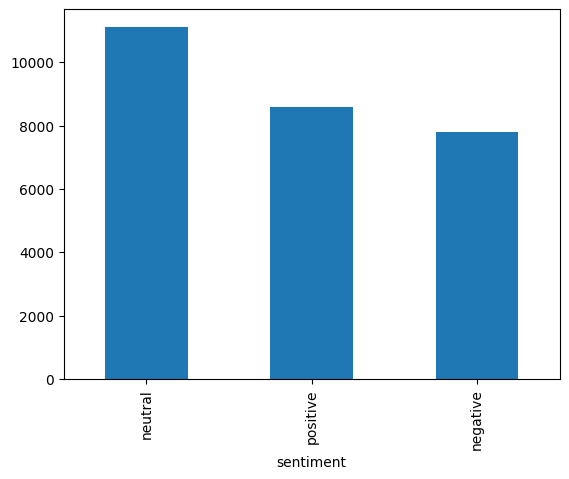

In [10]:
raw_df["sentiment"].value_counts().plot(kind="bar")

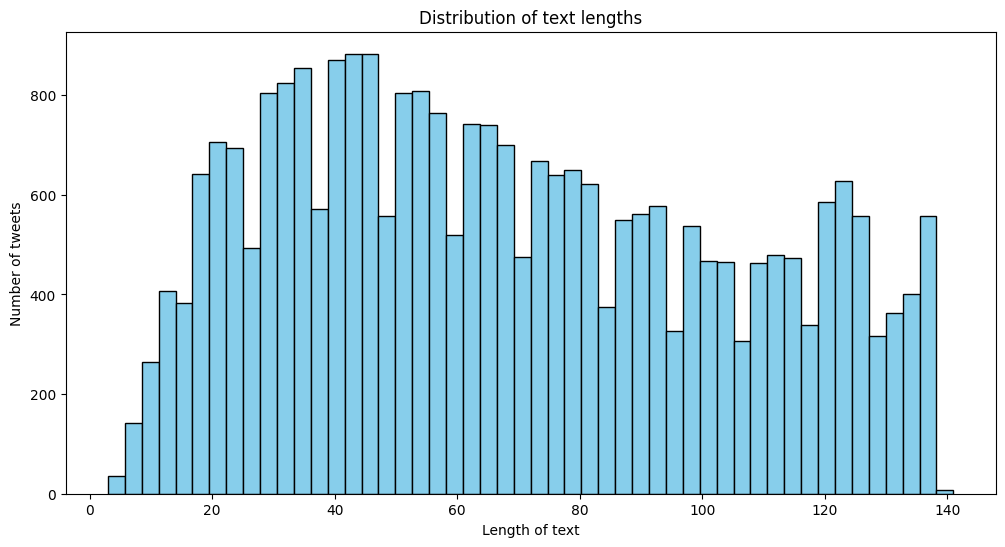

In [11]:
raw_df["text_len"] = raw_df["text"].str.len()

plt.figure(figsize=(12, 6))
plt.hist(raw_df["text_len"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of text lengths")
plt.xlabel("Length of text")
plt.ylabel("Number of tweets")
plt.show()

In [12]:
print(raw_df["text_len"].describe())

count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_len, dtype: float64


### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [13]:
english_stopwords = stopwords.words("english")
stemmer = SnowballStemmer(language="english")

In [14]:
def tokenize(text):
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text.lower())
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens_no_stop = [word for word in tokens if word.lower() not in english_stopwords]
    return [stemmer.stem(word) for word in tokens_no_stop]

In [15]:
vectorizer_count = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    token_pattern=None,
    max_features=15000,
    ngram_range=(1, 2),
    min_df=5,
)
X_bow = vectorizer_count.fit_transform(raw_df["text"])
print(f"Dictionary size: {len(vectorizer_count.vocabulary_)}")

Dictionary size: 6145


In [16]:
features_count = vectorizer_count.get_feature_names_out()

In [17]:
print(features_count[:100])

['aaaah' 'aah' 'abandon' 'abbi' 'abil' 'abit' 'abl' 'abl get' 'abl talk'
 'absolut' 'absolut love' 'abt' 'ac' 'academi' 'accept' 'access' 'accid'
 'accident' 'accomplish' 'accord' 'account' 'ace' 'ace cake' 'ach'
 'achiev' 'ack' 'across' 'act' 'act like' 'action' 'activ' 'actor'
 'actress' 'actual' 'actual realli' 'ad' 'adam' 'add' 'addict' 'address'
 'admir' 'admit' 'adopt' 'ador' 'adult' 'advanc' 'advantag' 'adventur'
 'advert' 'advic' 'affect' 'afford' 'afraid' 'afternoon' 'afterward' 'age'
 'agh' 'ago' 'agre' 'ah' 'ah well' 'aha' 'ahaha' 'ahahaha' 'ahead' 'ahh'
 'ahh im' 'ahhh' 'ahhhh' 'ahhhhh' 'ahhhhhh' 'aight' 'aim' 'aint' 'air'
 'airport' 'aka' 'ako' 'al' 'ala' 'alarm' 'album' 'alcohol' 'alex' 'alexi'
 'algebra' 'ali' 'alic' 'alien' 'aliv' 'allah' 'allen' 'allerg' 'allergi'
 'allll' 'alllll' 'allow' 'almost' 'almost done' 'almost got']


In [18]:
print(features_count[::50])

['aaaah' 'affect' 'alon' 'anoth note' 'articl' 'awesom day' 'bad im'
 'beard' 'best wish' 'blink' 'bow' 'bruce' 'cach' 'cant stand' 'chair'
 'chines' 'cnt' 'commit' 'cool peopl' 'crappi' 'cutest' 'day everyon'
 'day wish' 'design' 'dis' 'done day' 'downstair' 'earli night' 'empir'
 'even though' 'expect' 'faster' 'ffs' 'flat' 'forth' 'full day' 'georg'
 'get see' 'glasgow' 'go sleep' 'good love' 'got excit' 'great one'
 'guy like' 'happen today' 'hd' 'hey hey' 'home get' 'hope ill' 'huge'
 'ill come' 'im fan' 'im sit' 'indi' 'itchi' 'jet' 'kate' 'know feel'
 'languag' 'least' 'like day' 'listen music' 'lol well' 'lovato' 'lunch'
 'makin' 'mayb one' 'microsoft' 'miss show' 'month' 'mtv' 'na see'
 'need surgeri' 'new pic' 'night twitter' 'nyc' 'ok back' 'one want' 'pad'
 'pen' 'ping' 'pm' 'prejudic' 'prom' 'race' 'realli disappoint' 'region'
 'rice' 'rude' 'save' 'search' 'septemb' 'show tonight' 'skin' 'sneak'
 'soon get' 'spam' 'star trek' 'still like' 'stuck traffic' 'suppos go'
 'ta 

In [19]:
print(features_count[-100:])

['wt' 'wtf' 'wth' 'wud' 'wut' 'x' 'xbox' 'xd' 'xmen' 'xmen origin' 'xo'
 'xox' 'xoxo' 'xxxx' 'ya' 'yaaaay' 'yaay' 'yah' 'yahoo' 'yall' 'yard'
 'yay' 'yay good' 'yayi' 'yea' 'yeah' 'yeah good' 'yeah guess' 'yeah im'
 'yeah know' 'yeah like' 'yeah love' 'yeah man' 'yeah right' 'yeah that'
 'yeah think' 'yeah yeah' 'yeahh' 'yeahhh' 'year' 'year ago' 'year old'
 'yearbook' 'yeh' 'yell' 'yellow' 'yep' 'yer' 'yes' 'yes im' 'yes know'
 'yes love' 'yes pleas' 'yes realli' 'yes thank' 'yes yes' 'yess' 'yesss'
 'yesterday' 'yet' 'yet anoth' 'yet im' 'yey' 'yo' 'yoga' 'yogurt' 'york'
 'youd' 'youll' 'youll get' 'young' 'younger' 'your' 'your best'
 'your feel' 'your go' 'your gon' 'your great' 'your right' 'your still'
 'your welcom' 'yous' 'youth' 'youtub' 'youv' 'youv got' 'yr' 'yr old'
 'yrs' 'yt' 'yu' 'yucki' 'yum' 'yummi' 'yup' 'zealand' 'zero' 'zombi'
 'zone' 'zoo']


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [20]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_probs = model.predict_proba(X_train)
    test_probs = model.predict_proba(X_test)

    print(
        "ROC_AUC Train:",
        round(
            roc_auc_score(y_train, train_probs, multi_class="ovr", average="weighted"),
            4,
        ),
    )
    print(
        "ROC_AUC Test:",
        round(
            roc_auc_score(y_test, test_probs, multi_class="ovr", average="weighted"), 4
        ),
    )
    print(
        "\nClassification Report Train:\n", classification_report(y_train, train_preds)
    )
    print("\nClassification Report Test:\n", classification_report(y_test, test_preds))

In [21]:
raw_df["target"] = raw_df["sentiment"].map({"negative": 0, "neutral": 1, "positive": 2})
y = raw_df["target"]

In [22]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
param_random_lr = {
    "estimator__C": [0.03, 0.05, 0.08, 0.1],
    "estimator__penalty": ["l1", "l2"],
    "estimator__class_weight": ["balanced", None],
}
model_lr = OneVsRestClassifier(
    LogisticRegression(solver="liblinear", max_iter=1000, random_state=42)
)

random_search_lr = RandomizedSearchCV(
    model_lr,
    param_random_lr,
    n_iter=50,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    verbose=1,
    n_jobs=-1,
)
random_search_lr.fit(X_train_bow, y_train)

best_model_lr = random_search_lr.best_estimator_

print(f"Best hyperparameters for Logistic Regression: {random_search_lr.best_params_}")
evaluate_model(best_model_lr, X_train_bow, y_train, X_test_bow, y_test)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best hyperparameters for Logistic Regression: {'estimator__penalty': 'l2', 'estimator__class_weight': 'balanced', 'estimator__C': 0.1}
ROC_AUC Train: 0.8856
ROC_AUC Test: 0.8297

Classification Report Train:
               precision    recall  f1-score   support

           0       0.76      0.72      0.74      6225
           1       0.72      0.76      0.74      8894
           2       0.79      0.78      0.79      6865

    accuracy                           0.75     21984
   macro avg       0.76      0.75      0.75     21984
weighted avg       0.76      0.75      0.75     21984


Classification Report Test:
               precision    recall  f1-score   support

           0       0.70      0.66      0.68      1556
           1       0.65      0.71      0.68      2223
           2       0.76      0.72      0.74      1717

    accuracy                           0.70      5496
   macro avg       0.70      0.70      0.70    

In [24]:
param_random_rf = {
    "n_estimators": [100, 200, 300],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [3, 6, 9],
}

model_rf = RandomForestClassifier(random_state=42)

random_search_rf = RandomizedSearchCV(
    model_rf,
    param_random_rf,
    n_iter=50,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    verbose=1,
    n_jobs=-1,
)
random_search_rf.fit(X_train_bow, y_train)

best_model_rf = random_search_rf.best_estimator_

print(f"Best hyperparameters for Random Forest: {random_search_rf.best_params_}")
evaluate_model(best_model_rf, X_train_bow, y_train, X_test_bow, y_test)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best hyperparameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini'}
ROC_AUC Train: 0.8949
ROC_AUC Test: 0.8473

Classification Report Train:
               precision    recall  f1-score   support

           0       0.78      0.68      0.72      6225
           1       0.71      0.75      0.73      8894
           2       0.75      0.79      0.77      6865

    accuracy                           0.74     21984
   macro avg       0.75      0.74      0.74     21984
weighted avg       0.75      0.74      0.74     21984


Classification Report Test:
               precision    recall  f1-score   support

           0       0.75      0.63      0.68      1556
           1       0.66      0.72      0.69      2223
           2       0.74      0.76      0.75      1717

    accuracy                           0.71      5496
   macro

In [25]:
param_random_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.1, 0.2],
    "reg_lambda": [1, 5, 10],
    "subsample": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "colsample_bytree": [0.8, 1.0],
}

model_xgb = XGBClassifier(
    use_label_encoder=False, eval_metric="mlogloss", random_state=42
)

random_search_xgb = RandomizedSearchCV(
    model_xgb,
    param_random_xgb,
    n_iter=50,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    verbose=1,
    n_jobs=-1,
)
random_search_xgb.fit(X_train_bow, y_train)

best_model_xgb = random_search_xgb.best_estimator_

print(f"Best hyperparameters for XGBoost: {random_search_xgb.best_params_}")
evaluate_model(best_model_xgb, X_train_bow, y_train, X_test_bow, y_test)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best hyperparameters for XGBoost: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.2, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
ROC_AUC Train: 0.8749
ROC_AUC Test: 0.8339

Classification Report Train:
               precision    recall  f1-score   support

           0       0.81      0.57      0.67      6225
           1       0.65      0.83      0.73      8894
           2       0.80      0.74      0.77      6865

    accuracy                           0.73     21984
   macro avg       0.76      0.71      0.72     21984
weighted avg       0.75      0.73      0.73     21984


Classification Report Test:
               precision    recall  f1-score   support

           0       0.76      0.54      0.63      1556
           1       0.61      0.79      0.69      2223
           2       0.77      0.69      0.73      1717

    accuracy                

Було протестовано три алгоритми класифікації: LogisticRegression, Random Forest та XGBoost. Найвищу якість за метрикою ROC-AUC на тестових даних показав Random Forest 0.847 та XGBoost 0.834. За показником Weighted F1 ці моделі продемонстрували схожий результат — близько 0.70-0.71. Класифікацію можна оцінити як задовільну для даного типу даних. Перенавчання присутнє, що мабудь зумовлено короткими текстами у соціальних мережах, який важко повністю усунути.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


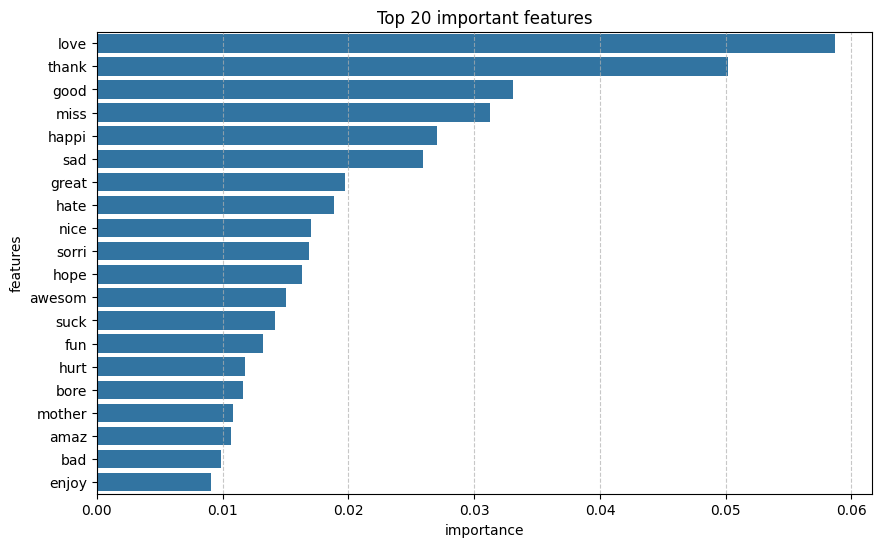

Top 20 most important words:

1. love: 0.0587
2. thank: 0.0501
3. good: 0.0331
4. miss: 0.0313
5. happi: 0.0270
6. sad: 0.0259
7. great: 0.0198
8. hate: 0.0188
9. nice: 0.0170
10. sorri: 0.0168
11. hope: 0.0163
12. awesom: 0.0150
13. suck: 0.0142
14. fun: 0.0132
15. hurt: 0.0118
16. bore: 0.0116
17. mother: 0.0108
18. amaz: 0.0107
19. bad: 0.0099
20. enjoy: 0.0090


In [26]:
importance_df = pd.DataFrame(
    {"features": features_count, "importance": best_model_rf.feature_importances_}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="features", data=importance_df.head(20))
plt.title("Top 20 important features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

importances = best_model_rf.feature_importances_
sorted_importances = sorted(enumerate(importances), key=lambda x: x[1], reverse=True)

print("Top 20 most important words:\n")
for i, (idx, importance) in enumerate(sorted_importances[:20]):
    word = features_count[idx]
    print(f"{i+1}. {word}: {importance:.4f}")

Аналіз за допомогою feature mportances моделі Random Forest показав, що найбільш впливовими словами є слова love (0.0587), thank (0.0501) та good (0.0331). На мій погляд, такий розподіл є логічним, оскільки в коротких текстах зазвичай висловлюють емоції максимально прямолінійно. Модель успішно ідентифікувала ключові маркери сентименту: як позитивні (good, happi, great), так і негативні (sad, hate, suck). Також цікавим є високий вплив слова miss, що характерно для повідомлень у соціальних мережах, де люди висловлюють сум за кимось.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [27]:
vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    token_pattern=None,
    max_features=15000,
    ngram_range=(1, 2),
    min_df=5,
)

X_tfidf = vectorizer_tfidf.fit_transform(raw_df["text"])
print(f"Dictionary size: {len(vectorizer_tfidf.vocabulary_)}")

Dictionary size: 6145


In [28]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
param_random_rf = {
    "n_estimators": [100, 200, 300],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [2, 4, 8],
}

model_rf_tfidf = RandomForestClassifier(random_state=42)

random_search_rf_tfidf = RandomizedSearchCV(
    model_rf_tfidf,
    param_random_rf,
    n_iter=50,
    cv=3,
    scoring="f1_weighted",
    random_state=42,
    verbose=1,
    n_jobs=-1,
)
random_search_rf_tfidf.fit(X_train_tfidf, y_train)

best_model_rf_tfidf = random_search_rf_tfidf.best_estimator_

print(f"Best hyperparameters for Random Forest: {random_search_rf_tfidf.best_params_}")
evaluate_model(best_model_rf_tfidf, X_train_tfidf, y_train, X_test_tfidf, y_test)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best hyperparameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}
ROC_AUC Train: 0.9382
ROC_AUC Test: 0.8442

Classification Report Train:
               precision    recall  f1-score   support

           0       0.84      0.75      0.80      6225
           1       0.78      0.81      0.79      8894
           2       0.80      0.84      0.82      6865

    accuracy                           0.80     21984
   macro avg       0.81      0.80      0.80     21984
weighted avg       0.80      0.80      0.80     21984


Classification Report Test:
               precision    recall  f1-score   support

           0       0.74      0.60      0.67      1556
           1       0.65      0.72      0.68      2223
           2       0.74      0.75      0.75      1717

    accuracy                           0.70      5496
   ma

In [30]:
features_tfidf = vectorizer_tfidf.get_feature_names_out()

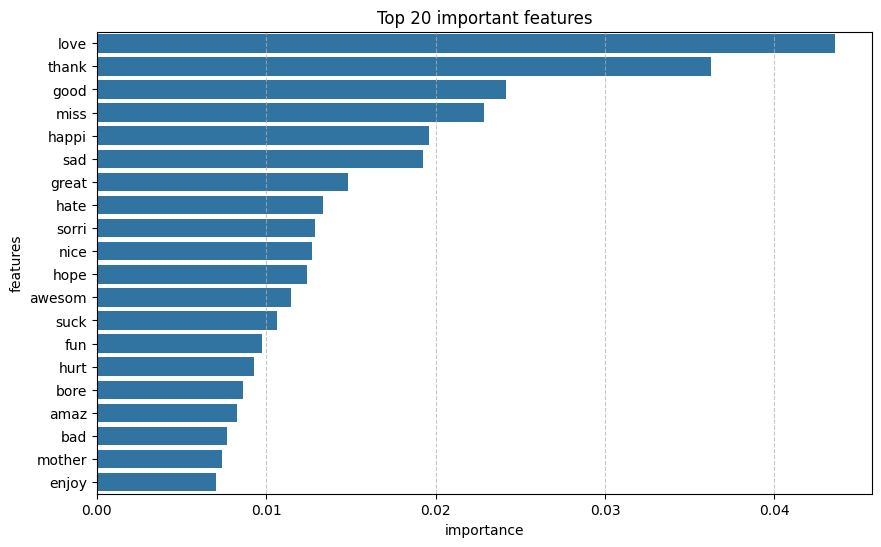

Top 20 most important words:

1. love: 0.0436
2. thank: 0.0363
3. good: 0.0241
4. miss: 0.0229
5. happi: 0.0196
6. sad: 0.0192
7. great: 0.0148
8. hate: 0.0134
9. sorri: 0.0129
10. nice: 0.0127
11. hope: 0.0124
12. awesom: 0.0115
13. suck: 0.0106
14. fun: 0.0097
15. hurt: 0.0093
16. bore: 0.0086
17. amaz: 0.0082
18. bad: 0.0077
19. mother: 0.0074
20. enjoy: 0.0070


In [31]:
importance_df_tfidf = pd.DataFrame(
    {"features": features_tfidf, "importance": best_model_rf_tfidf.feature_importances_}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="features", data=importance_df_tfidf.head(20))
plt.title("Top 20 important features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

importances_tfidf = best_model_rf_tfidf.feature_importances_
sorted_importances_tfidf = sorted(
    enumerate(importances_tfidf), key=lambda x: x[1], reverse=True
)

print("Top 20 most important words:\n")
for i, (idx, importance) in enumerate(sorted_importances_tfidf[:20]):
    word = features_tfidf[idx]
    print(f"{i+1}. {word}: {importance:.4f}")

In [32]:
print("Comparing the importance of words:\n")
for i, ((word_bow, imp_bow), (word_tfidf, imp_tfidf)) in enumerate(
    zip(sorted_importances[:20], sorted_importances_tfidf[:20])
):
    word_bow = features_count[word_bow]
    word_tfidf = features_tfidf[word_tfidf]
    print(
        f"{i+1}. Bag of Words: {word_bow} ({imp_bow:.4f}), TF-IDF: {word_tfidf} ({imp_tfidf:.4f})"
    )

Comparing the importance of words:

1. Bag of Words: love (0.0587), TF-IDF: love (0.0436)
2. Bag of Words: thank (0.0501), TF-IDF: thank (0.0363)
3. Bag of Words: good (0.0331), TF-IDF: good (0.0241)
4. Bag of Words: miss (0.0313), TF-IDF: miss (0.0229)
5. Bag of Words: happi (0.0270), TF-IDF: happi (0.0196)
6. Bag of Words: sad (0.0259), TF-IDF: sad (0.0192)
7. Bag of Words: great (0.0198), TF-IDF: great (0.0148)
8. Bag of Words: hate (0.0188), TF-IDF: hate (0.0134)
9. Bag of Words: nice (0.0170), TF-IDF: sorri (0.0129)
10. Bag of Words: sorri (0.0168), TF-IDF: nice (0.0127)
11. Bag of Words: hope (0.0163), TF-IDF: hope (0.0124)
12. Bag of Words: awesom (0.0150), TF-IDF: awesom (0.0115)
13. Bag of Words: suck (0.0142), TF-IDF: suck (0.0106)
14. Bag of Words: fun (0.0132), TF-IDF: fun (0.0097)
15. Bag of Words: hurt (0.0118), TF-IDF: hurt (0.0093)
16. Bag of Words: bore (0.0116), TF-IDF: bore (0.0086)
17. Bag of Words: mother (0.0108), TF-IDF: amaz (0.0082)
18. Bag of Words: amaz (0.01

При використанні моделі Random Forest обидва методи векторизації показали майже ідентичні результати (f1-score 0.70-0.71). Метод TF-IDF призвів до більшого перенавчання моделі (ROC-AUC на трейні 0.938 проти 0.895 у BoW), але не покращив якість на тестових даних. Найважливіші токени в обох випадках залишилися незмінними: love, thank, good, miss, happi. Це підтверджує, що для аналізу настрою ключовими є сильні емоційній слова. Невелика розбіжність у токенах mother day у BoW проти mother у TF-IDF не вплинула на загальну здатність моделі класифікувати тексти.

Для фінальної імплементації я б обрав Bag of Words (BoW). BoW показав трохи менше перенавчання та вищий ROC-AUC та f1-score на тестових даних.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [ ]:
y_pred_tfidf = best_model_rf_tfidf.predict(X_test_tfidf)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    raw_df["text"], y, test_size=0.2, random_state=42, stratify=y
)
y_test_values = y_test.values
wrong_indices = [
    i for i in range(len(y_test_values)) if y_pred_tfidf[i] != y_test_values[i]
]
wrong_samples = pd.DataFrame(
    {
        "text": X_test_text.iloc[wrong_indices].values,
        "target": y_test_values[wrong_indices],
        "pred": y_pred_tfidf[wrong_indices],
    }
)
print(f"Number of errors: {len(wrong_samples)}")
print(wrong_samples.head(15))

Number of errors: 1663
                                                 text  target  pred
0   Reading and taking notes but undertanding none...       0     1
1   Hoping that this will just heal on it`s own be...       1     2
2                    i`m just sooo in love....i think       2     1
3   Having a wonderful piece of cake for lunch - w...       2     1
4   shack idol today(: can`t wait. it`s gonna be f...       1     0
5                   Awww, *hugs* I wish I could help.       0     2
6   2 hours after teleconference. but can`t go bac...       0     1
7   Youtube isn`t working...and I wanted to watch ...       0     1
8    **** Frat - that`s too bad...  Should be a go...       1     2
9   ahhhhh **** it..... none of my friends want to...       0     1
10            Im home where i am about 2 drink alone.       0     1
11          _Jamie I guess  ! I was really suprised..       2     1
12  Rachel Allens date bars, so easy to make   htt...       2     1
13   _KittyKat hello new 

Аналіз деяких помилок:

_Jamie I guess  ! I was really suprised... — рядок з помилкою в слові suprised замість surprised. Через опечатку стеммер міг не впізнати слово, або воно отримало низьку вагу.

ahhhhh **** it..... none of my friends want to... — це випадок з цензурою. Текст містить "****" (замість матюків) та вигук "ahhhhh".

TAwww, *hugs* I wish I could help. — модель бачить hugs (обійми) та help (допомога), для моделі це добрі слова.

Youtube isn`t working...and I wanted to watch ... -  людина засмучена, а для моделі це нейтральні слова. Єдиний негатив тут — isn't.


Багато твітів містять емодзі або скорочення (наприклад, :), :(,  lol), які зараз токенізатор видаляє. Тож перед векторизацією замінити смайлики на відповідні слова наприклад, :) на emoji_positive. Це дасть моделі прямий сигнал про настрій.

Використання глибинного навчання (Deep Learning / BERT). Такі моделі розуміють контекст і зв'язки між словами, що допоможе краще класифікувати складні речення.

Більш ретельна чистка датасету від технічних повідомлень та розширення списку stopwords специфічними для Твіттера словами, які не впливають на сентимент, але створюють шум для моделі. 

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model